## Data Exploration and Cleaning

[Kaggle - Steam Review&Games Dataset](https://www.kaggle.com/datasets/filipkin/steam-reviews)


**Clean Kaggle Data**

In [10]:
import pandas as pd
import json
import os
import re
from langdetect import detect, LangDetectException
import matplotlib.pyplot as plt

In [ ]:
# Load the data
reviews_path = '../data/kaggle/game_reviews.csv'
games_path = '../data/kaggle/game_ids.csv'

reviews_df = pd.read_csv(reviews_path)
games_df = pd.read_csv(games_path)

print(f"Reviews: {len(reviews_df):,} rows")
print(f"Games: {len(games_df):,} rows")

# Merge reviews with game names on app_id
merged_df = reviews_df.merge(games_df, left_on='app_id', right_on='appid', how='left')

# Convert is_positive to boolean (True for Positive, False for Negative)
merged_df['is_positive'] = merged_df['is_positive'].str.strip().str.lower() == 'positive'

Reviews: 201,151 rows
Games: 1,000 rows


In [7]:
# ============ DATA CLEANING ============
print("\nCleaning data...")

# 1. Drop rows with missing game names or content
cleaned_df = merged_df.dropna(subset=['name', 'content'])
print(f"After dropping nulls: {len(cleaned_df):,}")

# 2. Convert content to string and strip whitespace
cleaned_df = cleaned_df.copy()
cleaned_df['content'] = cleaned_df['content'].astype(str).str.strip()

# 3. Remove empty reviews
cleaned_df = cleaned_df[cleaned_df['content'].str.len() > 0]
print(f"After removing empty: {len(cleaned_df):,}")

# 4. Remove reviews without at least one actual word (must have letters)
def has_valid_word(text):
    """Check if text contains at least one word with 2+ letters"""
    words = re.findall(r'[a-zA-Z]{2,}', text)
    return len(words) >= 1

cleaned_df = cleaned_df[cleaned_df['content'].apply(has_valid_word)]
print(f"After requiring valid words: {len(cleaned_df):,}")

# 5. Filter to English-only reviews
def is_english(text):
    """Detect if text is English using langdetect"""
    try:
        return detect(text) == 'en'
    except LangDetectException:
        return False

print("Filtering non-English reviews (this may take a few minutes)...")
cleaned_df = cleaned_df[cleaned_df['content'].apply(is_english)]
print(f"After English filter: {len(cleaned_df):,}")

# 6. Remove very short reviews (less than 20 characters after cleaning)
cleaned_df = cleaned_df[cleaned_df['content'].str.len() >= 20]
print(f"After min length filter: {len(cleaned_df):,}")

# Select only the columns we need
final_df = cleaned_df[['name', 'content', 'is_positive']].copy()
final_df.columns = ['game_name', 'review_content', 'is_positive']

print(f"\n=== Final Dataset ===")
print(f"Total reviews: {len(final_df):,}")
print(f"Positive reviews: {final_df['is_positive'].sum():,}")
print(f"Negative reviews: {(~final_df['is_positive']).sum():,}")


Cleaning data...
After dropping nulls: 191,655
After removing empty: 191,600
After requiring valid words: 183,466
Filtering non-English reviews (this may take a few minutes)...
After English filter: 135,200
After min length filter: 117,456

=== Final Dataset ===
Total reviews: 117,456
Positive reviews: 55,770
Negative reviews: 61,686


In [ ]:
# Convert to list of dictionaries for JSON
data_list = final_df.to_dict(orient='records')

# Save to JSON
output_dir = '../data/cleaned data'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'kaggle_data.json')
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(data_list, f, ensure_ascii=False, indent=2)

print(f"\nSaved to {output_path}")
print(f"\nSample entries:")
for i in range(min(3, len(data_list))):
    print(f"\n--- Review {i+1} ---")
    print(json.dumps(data_list[i], indent=2, ensure_ascii=False))

**Graphing Kaggle Data**

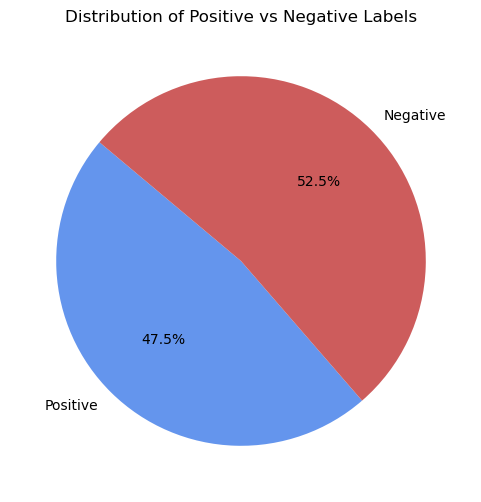

In [20]:
# Chart split of positive vs negative labels
positive_df = final_df[final_df['is_positive']]
negative_df = final_df[~final_df['is_positive']]

positive_count = len(positive_df)
negative_count = len(negative_df)
labels = ['Positive', 'Negative']
sizes = [positive_count, negative_count]
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['cornflowerblue', 'indianred'])
plt.title('Distribution of Positive vs Negative Labels')
plt.show()

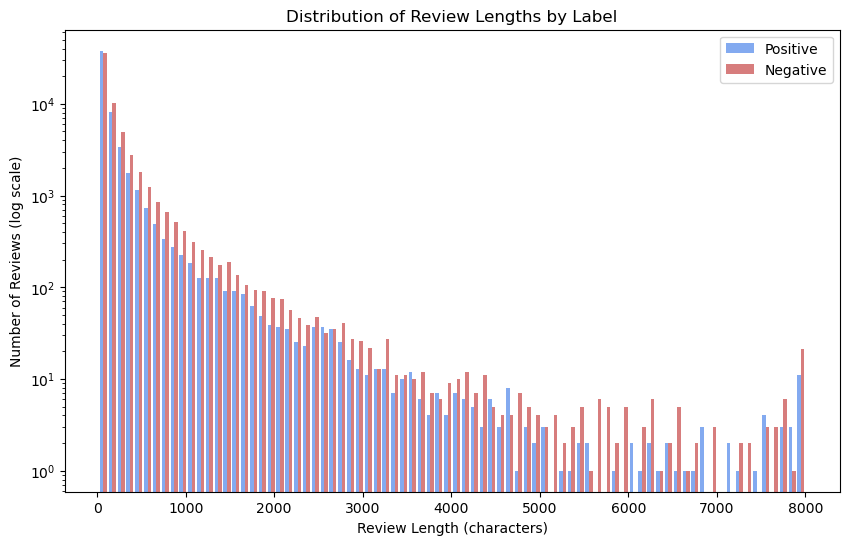

In [30]:
# Plot distribution of review lengths by label
positive_length = positive_df['review_content'].str.len()
negative_length = negative_df['review_content'].str.len()
plt.figure(figsize=(10, 6))
plt.hist([positive_length, negative_length], bins=80, alpha=0.8, label=['Positive', 'Negative'], color=['cornflowerblue', 'indianred'])
plt.yscale('log')
plt.xlabel('Review Length (characters)')
plt.ylabel('Number of Reviews (log scale)')
plt.legend()
plt.title('Distribution of Review Lengths by Label')
plt.show()



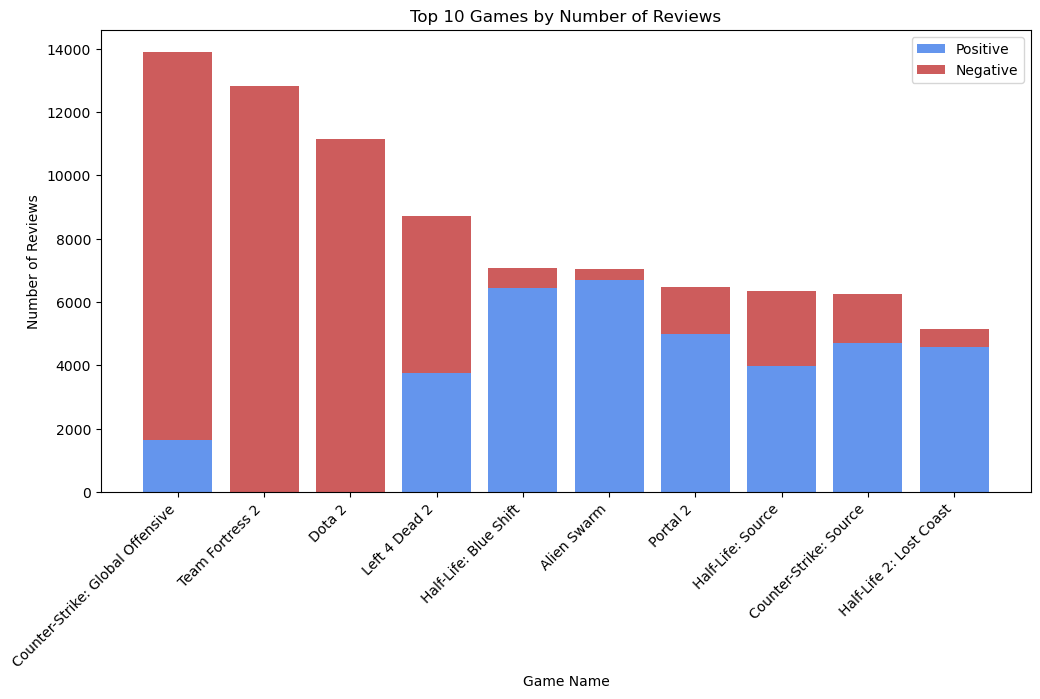

0
12825


In [ ]:
# Top 10 games by number of reviews
top_games = final_df['game_name'].value_counts(sort=True)[:10]
top_games_pos = [len(positive_df[positive_df['game_name'] == game]) for game in top_games.index]
top_games_neg = [len(negative_df[negative_df['game_name'] == game]) for game in top_games.index]

# Plot by stacked reviews
x = range(len(top_games)) # in case not 10
plt.figure(figsize=(12, 6))
plt.bar(x, top_games_pos, label='Positive', color='cornflowerblue')
plt.bar(x, top_games_neg, bottom=top_games_pos, label='Negative', color='indianred')
plt.xticks(x, top_games.index, rotation=45, ha='right')
plt.ylabel('Number of Reviews')
plt.xlabel('Game Name')
plt.title('Top 10 Games by Number of Reviews')
plt.legend()
plt.show()

# ??? This is not right!
print(len(positive_df[positive_df['game_name'] == 'Team Fortress 2']))
print(len(negative_df[negative_df['game_name'] == 'Team Fortress 2']))


**Clean Mendeley Data**

In [2]:
# ============ CLEAN MENDELEY DATA ============
import pandas as pd
import json
import os
import re
import random
from langdetect import detect, LangDetectException

# Helper functions
def has_valid_word(text):
    """Check if text contains at least one word with 2+ letters"""
    if pd.isna(text):
        return False
    words = re.findall(r'[a-zA-Z]{2,}', str(text))
    return len(words) >= 1

def is_english(text):
    """Detect if text is English using langdetect"""
    try:
        return detect(str(text)) == 'en'
    except LangDetectException:
        return False

# Load the game id to review count mapping
mendeley_review_counts = pd.read_csv('../cleaned_data/mendeley_id_to_review_num.csv')
mendeley_data_dir = '../data/mendeley data'

TARGET_RAW_REVIEWS = 250000
TARGET_FINAL_REVIEWS = 117000  # Match Kaggle

print("Sampling Mendeley games...")
all_reviews = []
total_sampled = 0

# Shuffle games to get random distribution
shuffled_games = mendeley_review_counts.sample(frac=1, random_state=42).reset_index(drop=True)

for _, row in shuffled_games.iterrows():
    if total_sampled >= TARGET_RAW_REVIEWS:
        break
    
    game_id = str(row['id'])
    num_reviews = row['num_reviews']
    file_name = f"{game_id}_{num_reviews}.csv"
    file_path = os.path.join(mendeley_data_dir, file_name)
    
    if os.path.exists(file_path):
        try:
            game_df = pd.read_csv(file_path)
            game_df['game_id'] = game_id
            all_reviews.append(game_df)
            total_sampled += len(game_df)
        except Exception as e:
            print(f"Error reading {file_name}: {e}")
    
    if len(all_reviews) % 500 == 0:
        print(f"Sampled {len(all_reviews)} games, {total_sampled:,} reviews...")

print(f"\nTotal raw reviews sampled: {total_sampled:,}")

# Combine all reviews
raw_df = pd.concat(all_reviews, ignore_index=True)
print(f"Combined DataFrame: {len(raw_df):,} rows")

Sampling Mendeley games...

Total raw reviews sampled: 283,598
Combined DataFrame: 283,598 rows


In [3]:
# ============ CLEANING STEPS ============
print("Cleaning Mendeley data...")

# 1. Drop rows with missing reviews
cleaned_df = raw_df.dropna(subset=['review'])
print(f"After dropping nulls: {len(cleaned_df):,}")

# 2. Convert review to string and strip whitespace
cleaned_df = cleaned_df.copy()
cleaned_df['review'] = cleaned_df['review'].astype(str).str.strip()

# 3. Remove empty reviews
cleaned_df = cleaned_df[cleaned_df['review'].str.len() > 0]
print(f"After removing empty: {len(cleaned_df):,}")

# 4. Remove reviews without at least one actual word (must have letters)
cleaned_df = cleaned_df[cleaned_df['review'].apply(has_valid_word)]
print(f"After requiring valid words: {len(cleaned_df):,}")

# 5. Filter to English-only reviews (this is the slow step)
print("Filtering non-English reviews (this may take a while)...")
cleaned_df = cleaned_df[cleaned_df['review'].apply(is_english)]
print(f"After English filter: {len(cleaned_df):,}")

# 6. Remove very short reviews (less than 20 characters)
cleaned_df = cleaned_df[cleaned_df['review'].str.len() >= 20]
print(f"After min length filter: {len(cleaned_df):,}")

Cleaning Mendeley data...
After dropping nulls: 282,359
After removing empty: 282,359
After requiring valid words: 213,598
Filtering non-English reviews (this may take a while)...
After English filter: 114,605
After min length filter: 102,576


In [4]:
# ============ BALANCE POSITIVE/NEGATIVE SPLIT ============
# Convert recommend to binary label for easier handling
cleaned_df['is_positive'] = cleaned_df['recommend'] == 'Recommended'

# Count current distribution
positive_reviews = cleaned_df[cleaned_df['is_positive']]
negative_reviews = cleaned_df[~cleaned_df['is_positive']]

print(f"\nBefore balancing:")
print(f"  Positive reviews: {len(positive_reviews):,}")
print(f"  Negative reviews: {len(negative_reviews):,}")

# Target: ~117k total with 50/50 split = ~58.5k each
TARGET_PER_CLASS = TARGET_FINAL_REVIEWS // 2  # ~58,500

# Sample from each class (use min to avoid sampling more than available)
n_positive = min(len(positive_reviews), TARGET_PER_CLASS)
n_negative = min(len(negative_reviews), TARGET_PER_CLASS)

# If one class has fewer, match the other to it for balance
n_samples = min(n_positive, n_negative)

print(f"\nSampling {n_samples:,} from each class...")
sampled_positive = positive_reviews.sample(n=n_samples, random_state=42)
sampled_negative = negative_reviews.sample(n=n_samples, random_state=42)

# Combine and shuffle
final_df = pd.concat([sampled_positive, sampled_negative], ignore_index=True)
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Drop the temporary is_positive column (keep original 'recommend' column)
final_df = final_df.drop(columns=['is_positive'])

print(f"\n=== Final Mendeley Dataset ===")
print(f"Total reviews: {len(final_df):,}")
print(f"Recommended: {(final_df['recommend'] == 'Recommended').sum():,}")
print(f"Not Recommended: {(final_df['recommend'] == 'Not Recommended').sum():,}")
print(f"Unique games: {final_df['game_id'].nunique():,}")
print(f"\nColumns: {list(final_df.columns)}")


Before balancing:
  Positive reviews: 75,616
  Negative reviews: 26,960

Sampling 26,960 from each class...

=== Final Mendeley Dataset ===
Total reviews: 53,920
Recommended: 26,960
Not Recommended: 26,960
Unique games: 97

Columns: ['user', 'playtime', 'post_date', 'helpfulness', 'review', 'recommend', 'early_access_review', 'game_id']


In [5]:
# ============ SAVE TO JSON AND CSV ============
output_dir = '../cleaned_data'
os.makedirs(output_dir, exist_ok=True)

# Save to CSV
csv_path = os.path.join(output_dir, 'mendeley_cleaned.csv')
final_df.to_csv(csv_path, index=False, encoding='utf-8')
print(f"Saved CSV to: {csv_path}")

# Save to JSON
json_path = os.path.join(output_dir, 'mendeley_cleaned.json')
data_list = final_df.to_dict(orient='records')
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(data_list, f, ensure_ascii=False, indent=2)
print(f"Saved JSON to: {json_path}")

# Show sample entries
print(f"\n=== Sample Entries ===")
for i in range(min(3, len(data_list))):
    print(f"\n--- Review {i+1} ---")
    sample = data_list[i].copy()
    # Truncate long reviews for display
    if len(sample['review']) > 200:
        sample['review'] = sample['review'][:200] + '...'
    print(json.dumps(sample, indent=2, ensure_ascii=False))

Saved CSV to: ../cleaned_data/mendeley_cleaned.csv
Saved JSON to: ../cleaned_data/mendeley_cleaned.json

=== Sample Entries ===

--- Review 1 ---
{
  "user": "tv/The7thDruid",
  "playtime": 319.5,
  "post_date": "May 9, 2017",
  "helpfulness": 1,
  "review": "no... Just no... might as well be a free to play game.",
  "recommend": "Not Recommended",
  "early_access_review": NaN,
  "game_id": "304390"
}

--- Review 2 ---
{
  "user": "PuddingArsch",
  "playtime": 291.2,
  "post_date": "February 10, 2022",
  "helpfulness": 0,
  "review": "memories are awakened",
  "recommend": "Recommended",
  "early_access_review": NaN,
  "game_id": "1466860"
}

--- Review 3 ---
{
  "user": "Caca",
  "playtime": 58.3,
  "post_date": "October 28, 2021",
  "helpfulness": 0,
  "review": "I can't spam 30? Refunded.",
  "recommend": "Recommended",
  "early_access_review": NaN,
  "game_id": "1466860"
}
